In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.optimize import minimize

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.4f}".format)

FIXED_LAM = 1.9675
TENOR_YEARS = {
    "1mo": 1/12, "3mo": 3/12, "6mo": 6/12,
    "1yr": 1, "2yr": 2, "3yr": 3, "5yr": 5,
    "7yr": 7, "10yr": 10, "20yr": 20, "30yr": 30,
}
TENORS = list(TENOR_YEARS.keys())
TAUS   = list(TENOR_YEARS.values())

def ns_yield(tau, beta0, beta1, beta2, lam=FIXED_LAM):
    tau = np.maximum(tau, 1e-6)
    factor = (1 - np.exp(-tau / lam)) / (tau / lam)
    return beta0 + beta1 * factor + beta2 * (factor - np.exp(-tau / lam))

In [2]:
portfolio  = pd.read_csv("data/portfolio.csv",      index_col="label")
krd        = pd.read_csv("data/krd.csv",            index_col="bond")
pnl_df     = pd.read_csv("data/scenario_pnl.csv",  index_col="scenario")
moves      = pd.read_csv("data/scenario_moves.csv", index_col="scenario")
scenarios  = pd.read_csv("data/scenarios.csv",      index_col="scenario")
base_curve = pd.read_csv("data/base_curve.csv",     index_col=0).iloc[:, 0]

# Portfolio-level risk metrics
port_price = portfolio["price"].sum()
port_dv01  = portfolio["dv01"].sum()
port_dur   = (portfolio["mod_dur"] * portfolio["price"]).sum() / port_price
port_krd   = (krd.T * portfolio["price"]).sum(axis=1) / port_price

print(f"Portfolio value   : ${port_price/1e6:.2f}M")
print(f"Portfolio DV01    : ${port_dv01:,.0f}")
print(f"Portfolio duration: {port_dur:.2f} years")
print(f"\nPortfolio KRD profile:")
for t, k in port_krd.items():
    print(f"  {t:>5s}: {k:.3f} years")

Portfolio value   : $51.55M
Portfolio DV01    : $45,581
Portfolio duration: 8.84 years

Portfolio KRD profile:
    1yr: 0.033 years
    2yr: 0.248 years
    3yr: 0.160 years
    5yr: 0.975 years
    7yr: 1.155 years
   10yr: 2.463 years
   20yr: 1.866 years
   30yr: 1.913 years


In [3]:
new_scenarios_def = {
    # Fed meeting shocks — short end only
    "fed_hike_25bps":    {**{"1mo": +25, "3mo": +25, "6mo": +25, "1yr": +25},
                          **{"2yr": 0, "3yr": 0, "5yr": 0, "7yr": 0,
                             "10yr": 0, "20yr": 0, "30yr": 0}},
    "fed_hike_50bps":    {**{"1mo": +50, "3mo": +50, "6mo": +50, "1yr": +50},
                          **{"2yr": 0, "3yr": 0, "5yr": 0, "7yr": 0,
                             "10yr": 0, "20yr": 0, "30yr": 0}},
    "fed_hike_75bps":    {**{"1mo": +75, "3mo": +75, "6mo": +75, "1yr": +75},
                          **{"2yr": 0, "3yr": 0, "5yr": 0, "7yr": 0,
                             "10yr": 0, "20yr": 0, "30yr": 0}},
    "fed_cut_25bps":     {**{"1mo": -25, "3mo": -25, "6mo": -25, "1yr": -25},
                          **{"2yr": 0, "3yr": 0, "5yr": 0, "7yr": 0,
                             "10yr": 0, "20yr": 0, "30yr": 0}},
    "fed_cut_50bps":     {**{"1mo": -50, "3mo": -50, "6mo": -50, "1yr": -50},
                          **{"2yr": 0, "3yr": 0, "5yr": 0, "7yr": 0,
                             "10yr": 0, "20yr": 0, "30yr": 0}},
    # Stagflation — long end up, short end flat
    "stagflation":       {**{"1mo": 0, "3mo": 0, "6mo": 0, "1yr": 0, "2yr": +50},
                          **{"3yr": +100, "5yr": +150, "7yr": +175,
                             "10yr": +200, "20yr": +200, "30yr": +200}},
    # Flight to quality — long end rallies, short end sells off
    "flight_to_quality": {**{"1mo": +50, "3mo": +50, "6mo": +50, "1yr": +25},
                          **{"2yr": 0, "3yr": -25, "5yr": -50, "7yr": -75,
                             "10yr": -100, "20yr": -100, "30yr": -100}},
}

# Build moves and stressed curves for new scenarios
new_curves = {}
new_moves  = {}
for name, shift_dict in new_scenarios_def.items():
    shifts           = np.array([shift_dict.get(t, 0) for t in TENORS])
    new_moves[name]  = shifts
    new_curves[name] = base_curve.values + shifts / 100

# Append to master library
new_curves_df = pd.DataFrame(new_curves, index=TENORS).T
new_moves_df  = pd.DataFrame(new_moves,  index=TENORS).T
new_curves_df.index.name = "scenario"
new_moves_df.index.name  = "scenario"

scenarios = pd.concat([scenarios, new_curves_df])
moves     = pd.concat([moves,     new_moves_df])

scenarios.to_csv("data/scenarios.csv")
moves.to_csv("data/scenario_moves.csv")

print(f"Scenario library: {len(scenarios)} total scenarios")
print(f"  Original : {len(scenarios) - len(new_scenarios_def)}")
print(f"  New      : {len(new_scenarios_def)}")
print(f"\nFull scenario list:")
for s in scenarios.index:
    tag = " ← NEW" if s in new_scenarios_def else ""
    print(f"  {s}{tag}")

Scenario library: 26 total scenarios
  Original : 19
  New      : 7

Full scenario list:
  parallel_up_100
  parallel_up_200
  parallel_up_300
  parallel_down_100
  parallel_down_200
  bear_steepener
  bull_steepener
  bear_flattener
  bull_flattener
  inversion
  hump
  taper_tantrum_2013
  covid_shock_2020
  rate_shock_2022
  mc_p5
  mc_p25
  mc_p50
  mc_p75
  mc_p95
  fed_hike_25bps ← NEW
  fed_hike_50bps ← NEW
  fed_hike_75bps ← NEW
  fed_cut_25bps ← NEW
  fed_cut_50bps ← NEW
  stagflation ← NEW
  flight_to_quality ← NEW


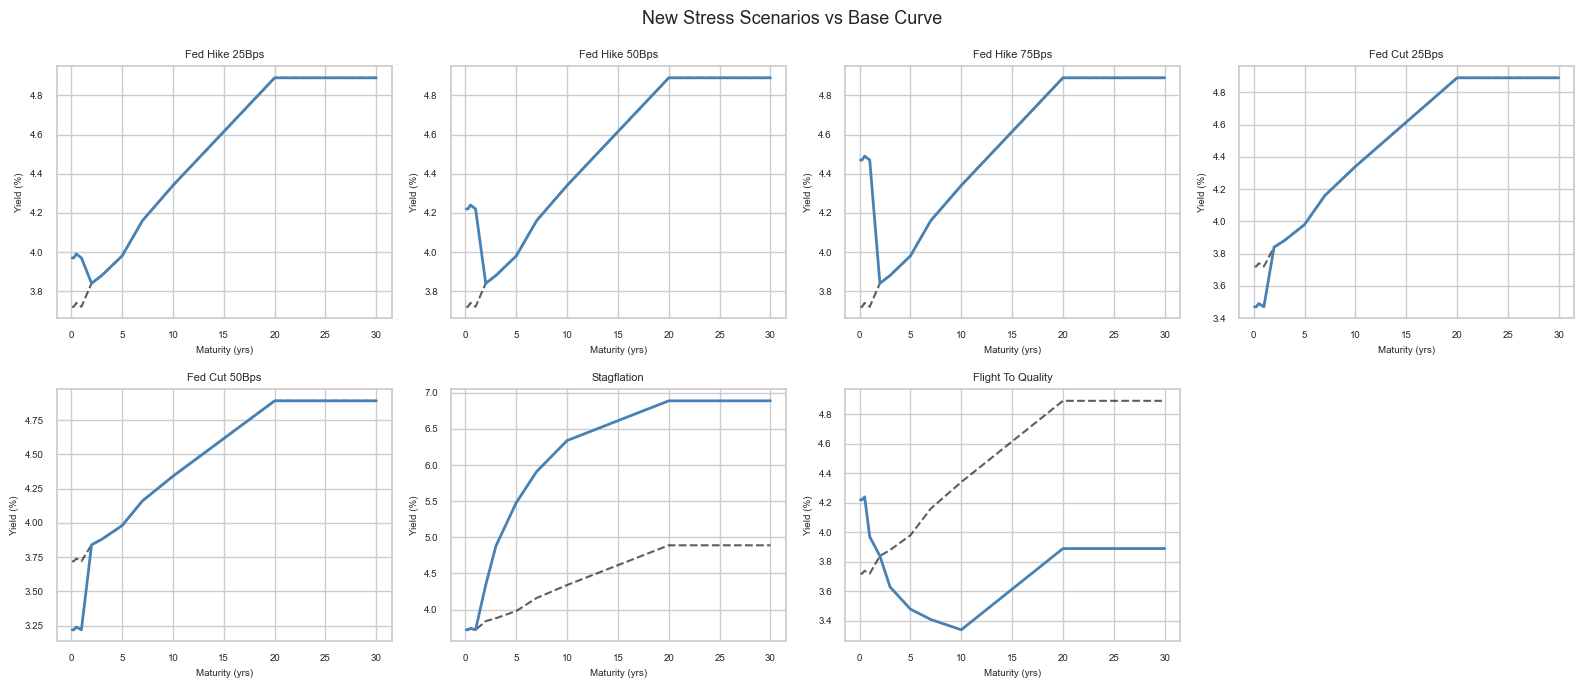

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, (name, curve) in zip(axes, new_curves.items()):
    ax.plot(TAUS, base_curve.values, "k--", linewidth=1.5,
            label="Base", alpha=0.7)
    ax.plot(TAUS, curve, "steelblue", linewidth=2)
    ax.set_title(name.replace("_"," ").title(), fontsize=8)
    ax.set_xlabel("Maturity (yrs)", fontsize=7)
    ax.set_ylabel("Yield (%)", fontsize=7)
    ax.tick_params(labelsize=7)

axes[-1].set_visible(False)
plt.suptitle("New Stress Scenarios vs Base Curve", fontsize=13)
plt.tight_layout()
plt.savefig("data/fig_new_scenario_curves.png", dpi=150)
plt.show()

In [5]:
futures = pd.DataFrame({
    "name":      ["2yr Note", "5yr Note", "10yr Note", "30yr Bond"],
    "ticker":    ["TU",       "FV",       "TY",        "US"],
    "dv01_per":  [40.0,       85.0,       160.0,       310.0],
    "krd_tenor": ["2yr",      "5yr",      "10yr",      "30yr"],
}, index=["TU", "FV", "TY", "US"])

TC_PER_CONTRACT = 0.5 * futures["dv01_per"]

print("Treasury Futures Specifications:")
print(futures[["name","dv01_per","krd_tenor"]].to_string())

Treasury Futures Specifications:
         name  dv01_per krd_tenor
TU   2yr Note   40.0000       2yr
FV   5yr Note   85.0000       5yr
TY  10yr Note  160.0000      10yr
US  30yr Bond  310.0000      30yr


In [6]:
def price_bond(coupon_rate, face, maturity_years, b0, b1, b2,
               freq=2, lam=FIXED_LAM):
    dt     = 1 / freq
    n_cf   = int(round(maturity_years * freq))
    coupon = coupon_rate * face / freq
    pv     = 0.0
    for i in range(1, n_cf + 1):
        t   = i * dt
        r_t = ns_yield(t, b0, b1, b2, lam) / 100
        df  = (1 + r_t / freq) ** (-i)
        cf  = coupon + (face if i == n_cf else 0)
        pv += cf * df
    return pv

def fit_ns_to_curve(target_yields_series, lam=FIXED_LAM):
    taus_arr = np.array(TAUS)
    tgt      = target_yields_series.values.astype(float)
    mask     = ~np.isnan(tgt)

    def obj(p):
        fitted = np.array([ns_yield(tau, p[0], p[1], p[2], lam)
                           for tau in taus_arr])
        return np.sum((fitted[mask] - tgt[mask])**2)

    best_rmse, best_p = np.inf, None
    for x0 in [[3,-1,0.5],[5,-2,1],[4,-1,-1],[4.5,-0.5,-2]]:
        res = minimize(obj, x0, method="L-BFGS-B",
                       bounds=[(0,15),(-10,10),(-10,10)])
        if res.fun < best_rmse:
            best_rmse, best_p = res.fun, res.x
    return best_p

print("Bond pricer and NS fitter loaded.")

Bond pricer and NS fitter loaded.


In [7]:
# Strategy 1 — Duration Neutral (TY only)
ty_dv01    = futures.loc["TY", "dv01_per"]
n_ty       = port_dv01 / ty_dv01
n_ty_round = round(n_ty)
residual_dv01_s1 = port_dv01 - n_ty_round * ty_dv01
tc_s1 = n_ty_round * TC_PER_CONTRACT["TY"]

# Strategy 2 — KRD Hedge
krd_tenors = ["2yr", "5yr", "10yr", "30yr"]
port_krd_dollar = {t: port_krd[t] * port_price for t in krd_tenors}
futures_krd_matrix = np.zeros((4, 4))
for i, tkr in enumerate(["TU", "FV", "TY", "US"]):
    krd_t = futures.loc[tkr, "krd_tenor"]
    j     = krd_tenors.index(krd_t)
    futures_krd_matrix[i, j] = futures.loc[tkr, "dv01_per"] / 0.0001

target_krd    = np.array([port_krd_dollar[t] for t in krd_tenors])
n_krd, _, _, _ = np.linalg.lstsq(futures_krd_matrix.T, target_krd, rcond=None)
n_krd_round   = np.round(n_krd).astype(int)
tc_s2 = sum(abs(n_krd_round[i]) * TC_PER_CONTRACT[tkr]
            for i, tkr in enumerate(["TU","FV","TY","US"]))

# Strategy 3 — Partial Hedge (optimal ratio)
non_mc_scenarios = [s for s in pnl_df.index if not s.startswith("mc_")]
unhedged_pnl     = pnl_df.loc[non_mc_scenarios, "total"].values

hedge_ratio_range = np.arange(0, 1.01, 0.05)
pnl_worst = []
for hr in hedge_ratio_range:
    n_contracts = round(n_ty * hr)
    hedged = []
    for sc in non_mc_scenarios:
        move_10yr = moves.loc[sc, "10yr"]
        fut_pnl   = -n_contracts * ty_dv01 * move_10yr
        hedged.append(pnl_df.loc[sc, "total"] + fut_pnl)
    pnl_worst.append(np.min(hedged))

optimal_ratio = hedge_ratio_range[np.argmin(pnl_worst)]
n_partial     = round(n_ty * optimal_ratio)
tc_s3         = n_partial * TC_PER_CONTRACT["TY"]

# Strategy 4 — Combined (KRD mix + full DV01)
s2_dv01_covered = sum(n_krd_round[i] * futures.loc[tkr, "dv01_per"]
                      for i, tkr in enumerate(["TU","FV","TY","US"]))
scale_factor = port_dv01 / s2_dv01_covered
n_s4 = {tkr: round(n_krd_round[i] * scale_factor)
        for i, tkr in enumerate(["TU","FV","TY","US"])}
tc_s4 = sum(abs(n_s4[tkr]) * TC_PER_CONTRACT[tkr]
            for tkr in ["TU","FV","TY","US"])

# Contract dictionaries
s1_contracts = {"TY": -n_ty_round}
s2_contracts = {tkr: -n_krd_round[i]
                for i, tkr in enumerate(["TU","FV","TY","US"])}
s3_contracts = {"TY": -n_partial}
s4_contracts = {"TU": -n_s4["TU"], "FV": -n_s4["FV"],
                "TY": -n_s4["TY"], "US": -n_s4["US"]}

print("HEDGE STRATEGIES DEFINED")
print("=" * 50)
print(f"S1 — TY only        : {n_ty_round} contracts  cost=${tc_s1:,.0f}")
print(f"S2 — KRD hedge      : TU={n_krd_round[0]} FV={n_krd_round[1]} "
      f"TY={n_krd_round[2]} US={n_krd_round[3]}  cost=${tc_s2:,.0f}")
print(f"S3 — Partial {optimal_ratio*100:.0f}%    : {n_partial} contracts  cost=${tc_s3:,.0f}")
print(f"S4 — Combined       : TU={n_s4['TU']} FV={n_s4['FV']} "
      f"TY={n_s4['TY']} US={n_s4['US']}  cost=${tc_s4:,.0f}")

HEDGE STRATEGIES DEFINED
S1 — TY only        : 285 contracts  cost=$22,800
S2 — KRD hedge      : TU=32 FV=59 TY=79 US=32  cost=$14,428
S3 — Partial 100%    : 285 contracts  cost=$22,800
S4 — Combined       : TU=51 FV=93 TY=125 US=51  cost=$22,878


In [8]:
def futures_pnl_strategy(contracts_dict, scenario_name=None,
                          override_moves=None):
    total    = 0
    sc_moves = (pd.Series(override_moves, index=TENORS)
                if override_moves is not None
                else moves.loc[scenario_name])
    for tkr, n in contracts_dict.items():
        krd_t    = futures.loc[tkr, "krd_tenor"]
        move_bps = sc_moves.get(krd_t, sc_moves.mean())
        dv01_c   = futures.loc[tkr, "dv01_per"]
        total   += -n * dv01_c * move_bps
    return total

print("futures_pnl_strategy loaded.")

futures_pnl_strategy loaded.


In [9]:
# All non-MC scenarios from the full updated library
all_scenarios_list = [s for s in scenarios.index
                      if not s.startswith("mc_")]

pnl_records    = []
hedged_records = []

for sc in all_scenarios_list:
    sc_curve = scenarios.loc[sc]
    sc_move  = moves.loc[sc].values

    # Fit NS and reprice
    b0s, b1s, b2s = fit_ns_to_curve(sc_curve)
    total_pnl = 0
    row_pnl   = {"scenario": sc}
    for bond_label, bond in portfolio.iterrows():
        p_stress = price_bond(bond["coupon"], bond["face"],
                              bond["maturity"], b0s, b1s, b2s)
        pnl = p_stress - bond["price"]
        row_pnl[bond_label] = pnl
        total_pnl += pnl
    row_pnl["total"] = total_pnl
    pnl_records.append(row_pnl)

    # Hedge P&L — use override_moves for all scenarios
    fpnl_s1 = futures_pnl_strategy(s1_contracts,
                                    override_moves=moves.loc[sc])
    fpnl_s2 = futures_pnl_strategy(s2_contracts,
                                    override_moves=moves.loc[sc])
    fpnl_s3 = futures_pnl_strategy(s3_contracts,
                                    override_moves=moves.loc[sc])
    fpnl_s4 = futures_pnl_strategy(s4_contracts,
                                    override_moves=moves.loc[sc])

    hedged_records.append({
        "scenario":   sc,
        "unhedged":   total_pnl,
        "s1_futures": fpnl_s1,
        "s2_futures": fpnl_s2,
        "s3_futures": fpnl_s3,
        "s4_futures": fpnl_s4,
        "s1_hedged":  total_pnl + fpnl_s1,
        "s2_hedged":  total_pnl + fpnl_s2,
        "s3_hedged":  total_pnl + fpnl_s3,
        "s4_hedged":  total_pnl + fpnl_s4,
    })

pnl_all    = pd.DataFrame(pnl_records).set_index("scenario")
hedged_df  = pd.DataFrame(hedged_records).set_index("scenario")

pnl_all.to_csv("data/scenario_pnl.csv")
hedged_df.to_csv("data/hedged_pnl.csv")
print(f"Repriced {len(pnl_all)} scenarios")
print(f"Worst unhedged: {pnl_all['total'].idxmin()} "
      f"(${pnl_all['total'].min()/1e3:,.1f}K)")
print(f"Best unhedged : {pnl_all['total'].idxmax()} "
      f"(${pnl_all['total'].max()/1e3:,.1f}K)")

Repriced 21 scenarios
Worst unhedged: parallel_up_300 ($-11,092.9K)
Best unhedged : parallel_down_200 ($10,734.1K)


In [10]:
def effectiveness(hedged_pnl, unhedged_pnl):
    if abs(unhedged_pnl) < 1:
        return np.nan
    return (1 - abs(hedged_pnl) / abs(unhedged_pnl)) * 100

eff_records = []
for sc in all_scenarios_list:
    row = hedged_df.loc[sc]
    unh = row["unhedged"]
    eff_records.append({
        "scenario":     sc,
        "unhedged_$K":  unh / 1e3,
        "s1_hedged_$K": row["s1_hedged"] / 1e3,
        "s2_hedged_$K": row["s2_hedged"] / 1e3,
        "s3_hedged_$K": row["s3_hedged"] / 1e3,
        "s4_hedged_$K": row["s4_hedged"] / 1e3,
        "s1_eff_%":     effectiveness(row["s1_hedged"], unh),
        "s2_eff_%":     effectiveness(row["s2_hedged"], unh),
        "s3_eff_%":     effectiveness(row["s3_hedged"], unh),
        "s4_eff_%":     effectiveness(row["s4_hedged"], unh),
    })

eff_df = pd.DataFrame(eff_records).set_index("scenario")
eff_df.to_csv("data/hedge_effectiveness.csv")

print("\nHEDGE EFFECTIVENESS — ALL SCENARIOS")
print("=" * 105)
print(f"{'Scenario':<25} {'Unhedged':>10} "
      f"{'S1($K)':>8} {'S1%':>6} "
      f"{'S2($K)':>8} {'S2%':>6} "
      f"{'S4($K)':>8} {'S4%':>6}")
print("-" * 105)
for sc in all_scenarios_list:
    r = hedged_df.loc[sc]
    e = eff_df.loc[sc]
    tag = " *" if sc in new_scenarios_def else ""
    print(f"{sc+tag:<25} "
          f"{r['unhedged']/1e3:>10,.1f} "
          f"{r['s1_hedged']/1e3:>8,.1f} {e['s1_eff_%']:>5.1f}% "
          f"{r['s2_hedged']/1e3:>8,.1f} {e['s2_eff_%']:>5.1f}% "
          f"{r['s4_hedged']/1e3:>8,.1f} {e['s4_eff_%']:>5.1f}%")

print("\n* = new scenario")
print(f"\nAverage effectiveness:")
print(f"  S1: {eff_df['s1_eff_%'].mean():.1f}%  "
      f"S2: {eff_df['s2_eff_%'].mean():.1f}%  "
      f"S4: {eff_df['s4_eff_%'].mean():.1f}%")


HEDGE EFFECTIVENESS — ALL SCENARIOS
Scenario                    Unhedged   S1($K)    S1%   S2($K)    S2%   S4($K)    S4%
---------------------------------------------------------------------------------------------------------
parallel_up_100             -4,232.6    327.4  92.3% -1,347.1  68.2%    342.9  91.9%
parallel_up_200             -7,896.1  1,223.9  84.5% -2,125.1  73.1%  1,254.9  84.1%
parallel_up_300            -11,092.9  2,587.1  76.7% -2,436.4  78.0%  2,633.6  76.3%
parallel_down_100            4,932.7    372.7  92.4%  2,047.2  58.5%    357.2  92.8%
parallel_down_200           10,734.1  1,614.1  85.0%  4,963.1  53.8%  1,583.1  85.3%
bear_steepener              -5,584.8  1,255.2  77.5% -1,384.6  75.2%  1,074.4  80.8%
bull_steepener               7,320.2    480.2  93.4%  3,120.0  57.4%    661.0  91.0%
bear_flattener              -2,191.9     88.1  96.0%   -621.2  71.7%    299.8  86.3%
bull_flattener               2,351.7     71.7  97.0%    780.9  66.8%   -140.1  94.0%
inversi

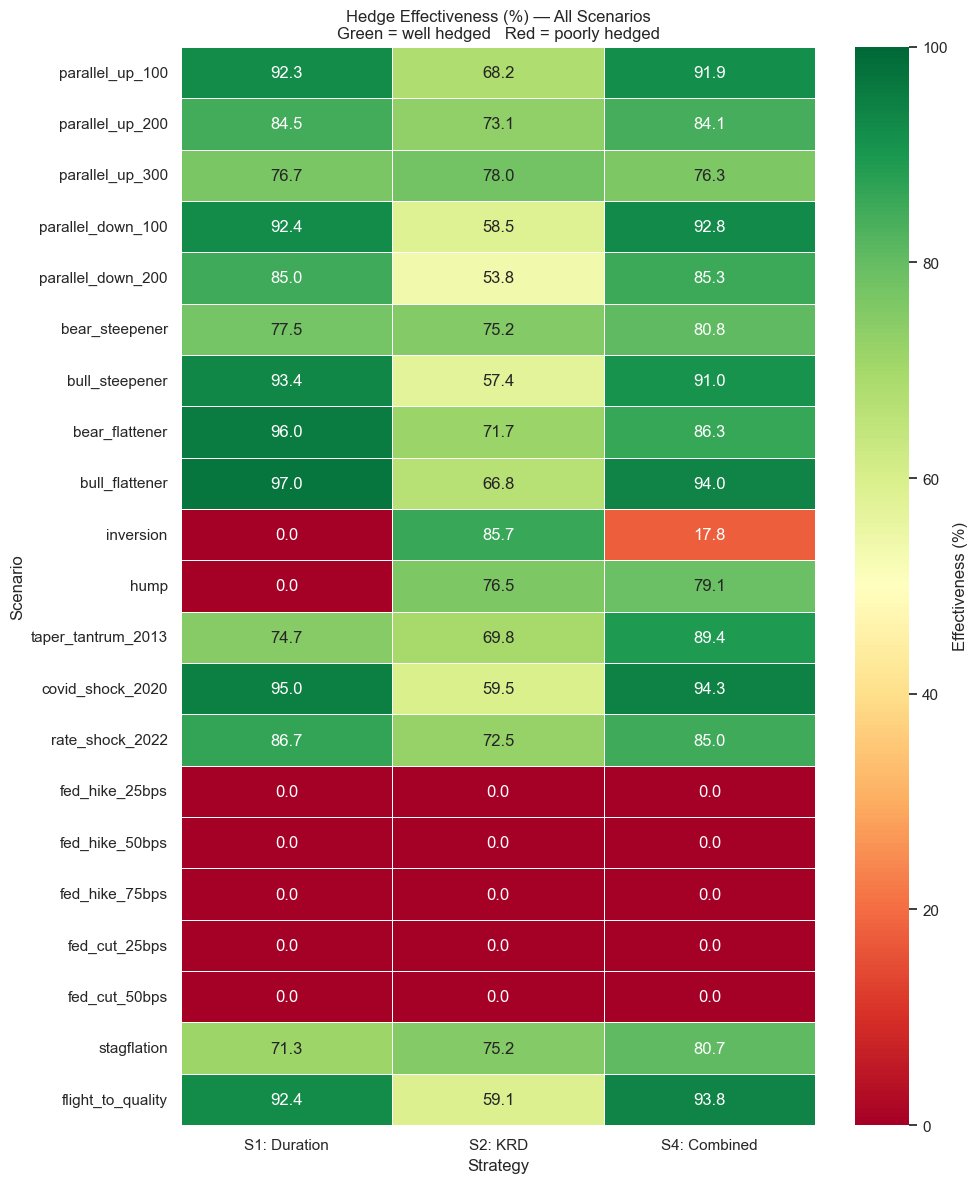

In [11]:
eff_matrix = eff_df[["s1_eff_%","s2_eff_%","s4_eff_%"]].copy()
eff_matrix.columns = ["S1: Duration", "S2: KRD", "S4: Combined"]

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(eff_matrix.astype(float),
            annot=True, fmt=".1f",
            cmap="RdYlGn", center=50,
            vmin=0, vmax=100,
            ax=ax, linewidths=0.5,
            cbar_kws={"label": "Effectiveness (%)"})
ax.set_title("Hedge Effectiveness (%) — All Scenarios\n"
             "Green = well hedged   Red = poorly hedged",
             fontsize=12)
ax.set_xlabel("Strategy")
ax.set_ylabel("Scenario")
plt.tight_layout()
plt.savefig("data/fig_effectiveness_heatmap.png", dpi=150)
plt.show()

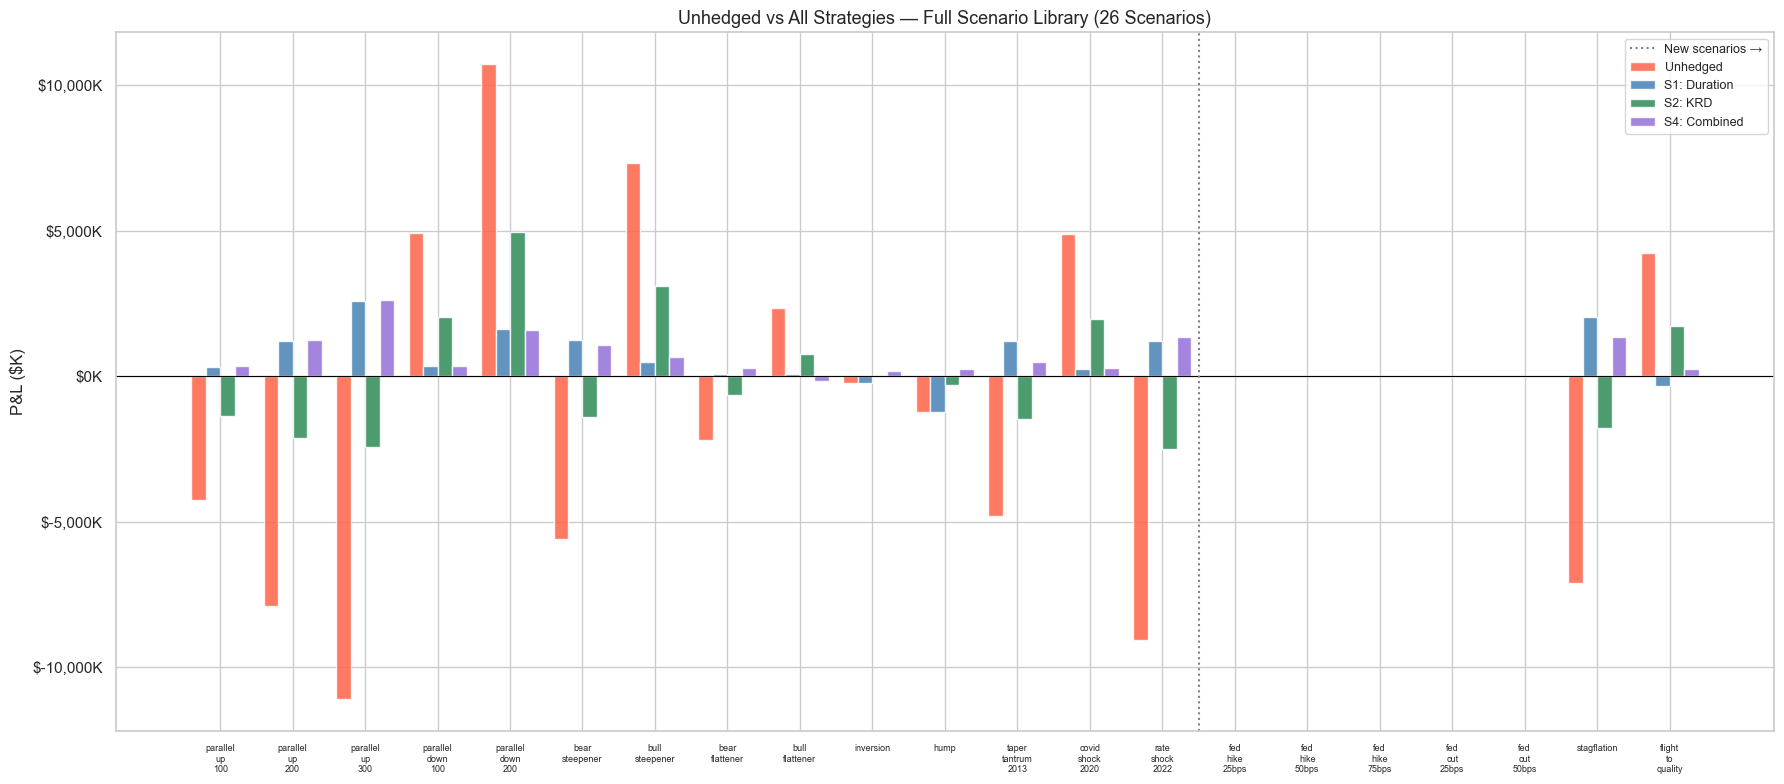

In [12]:
fig, ax = plt.subplots(figsize=(18, 8))

x     = np.arange(len(all_scenarios_list))
width = 0.20

ax.bar(x - width*1.5, hedged_df["unhedged"]  / 1e3, width,
       label="Unhedged",          color="tomato",       alpha=0.85, edgecolor="white")
ax.bar(x - width*0.5, hedged_df["s1_hedged"] / 1e3, width,
       label="S1: Duration",      color="steelblue",    alpha=0.85, edgecolor="white")
ax.bar(x + width*0.5, hedged_df["s2_hedged"] / 1e3, width,
       label="S2: KRD",           color="seagreen",     alpha=0.85, edgecolor="white")
ax.bar(x + width*1.5, hedged_df["s4_hedged"] / 1e3, width,
       label="S4: Combined",      color="mediumpurple", alpha=0.85, edgecolor="white")

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(len(non_mc_scenarios) - 0.5, color="gray",
           linestyle=":", linewidth=1.5, label="New scenarios →")
ax.set_xticks(x)
ax.set_xticklabels([s.replace("_","\n") for s in all_scenarios_list],
                   fontsize=6.5, rotation=0)
ax.set_ylabel("P&L ($K)")
ax.set_title("Unhedged vs All Strategies — Full Scenario Library (26 Scenarios)",
             fontsize=13)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
plt.tight_layout()
plt.savefig("data/fig_hero_all_scenarios.png", dpi=150)
plt.show()

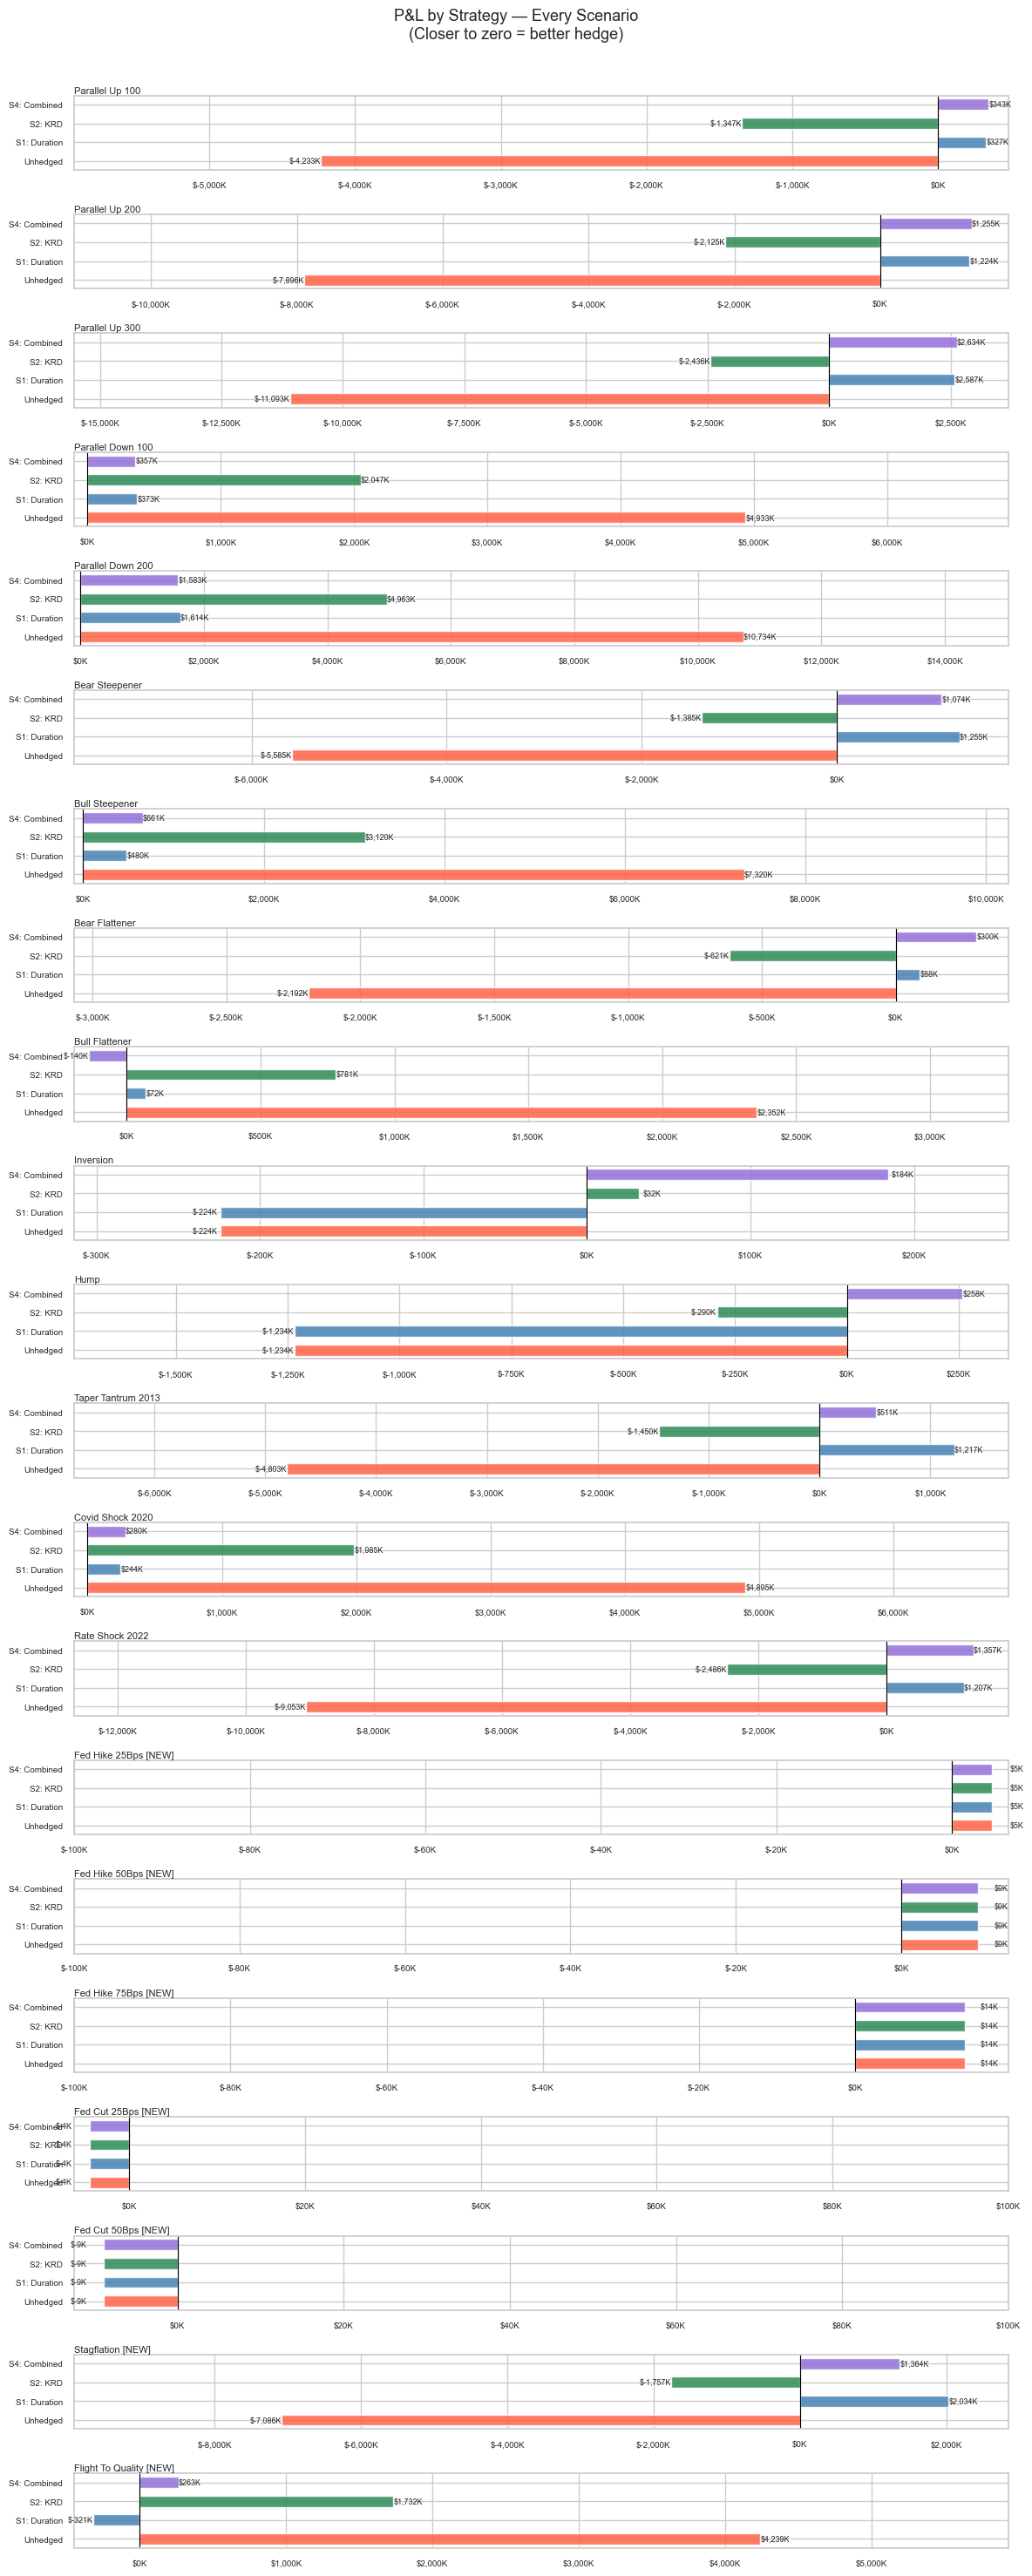

In [13]:
fig, axes = plt.subplots(len(all_scenarios_list), 1,
                         figsize=(12, len(all_scenarios_list) * 1.4))

for ax, sc in zip(axes, all_scenarios_list):
    vals   = [hedged_df.loc[sc, col] / 1e3
              for col in ["unhedged","s1_hedged","s2_hedged","s4_hedged"]]
    labels = ["Unhedged", "S1: Duration", "S2: KRD", "S4: Combined"]
    colors = ["tomato", "steelblue", "seagreen", "mediumpurple"]
    bars   = ax.barh(labels, vals, color=colors,
                     alpha=0.85, edgecolor="white", height=0.6)
    ax.axvline(0, color="black", linewidth=0.8)
    tag = " [NEW]" if sc in new_scenarios_def else ""
    ax.set_title(sc.replace("_"," ").title() + tag,
                 fontsize=8, loc="left", pad=2)
    lo = min(vals) * 1.4 if min(vals) < 0 else -100
    hi = max(vals) * 1.4 if max(vals) > 0 else 100
    ax.set_xlim(lo, hi)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
    ax.tick_params(axis="y", labelsize=7)
    ax.tick_params(axis="x", labelsize=7)
    for bar, val in zip(bars, vals):
        ax.text(val + (2 if val >= 0 else -2),
                bar.get_y() + bar.get_height()/2,
                f"${val:,.0f}K",
                va="center",
                ha="left" if val >= 0 else "right",
                fontsize=6.5)

plt.suptitle("P&L by Strategy — Every Scenario\n"
             "(Closer to zero = better hedge)",
             fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig("data/fig_per_scenario_detail.png", dpi=150)
plt.show()

In [14]:
# ── CELL 14: Cost vs Protection Summary ──────────────────────
print("HEDGING COST — STRATEGY 4 (Combined Hedge)")
print("=" * 55)
print("\nContracts to SHORT:")
for tkr in ["TU", "FV", "TY", "US"]:
    n    = n_s4[tkr]
    cost = n * TC_PER_CONTRACT[tkr]
    print(f"  {tkr} ({futures.loc[tkr,'name']:12s}): "
          f"{n:>4d} contracts  ×  ${TC_PER_CONTRACT[tkr]:.0f}/contract"
          f"  =  ${cost:,.0f}")

print(f"\n  Total contracts    : {sum(n_s4.values())}")
print(f"  Total hedge cost   : ${tc_s4:,.0f}")
print(f"  Portfolio value    : ${port_price/1e6:.2f}M")
print(f"  Cost as % of AUM   : {tc_s4/port_price*100:.4f}%")
print(f"  Cost per $1M hedged: ${tc_s4/(port_price/1e6):,.0f}")

worst_sc  = pnl_all["total"].idxmin()
worst_unh = pnl_all.loc[worst_sc, "total"]
worst_hdg = hedged_df.loc[worst_sc, "s4_hedged"]

print(f"\nCOST vs PROTECTION (worst scenario: {worst_sc}):")
print(f"  Unhedged loss  : ${worst_unh/1e3:,.1f}K")
print(f"  Hedged P&L     : ${worst_hdg/1e3:,.1f}K")
print(f"  Loss avoided   : ${(worst_unh - worst_hdg)/1e3:,.1f}K")
print(f"  Hedge cost     : ${tc_s4:,.0f}")
print(f"  Return on hedge: "
      f"{abs(worst_unh - worst_hdg)/tc_s4:.0f}x")

HEDGING COST — STRATEGY 4 (Combined Hedge)

Contracts to SHORT:
  TU (2yr Note    ):   51 contracts  ×  $20/contract  =  $1,020
  FV (5yr Note    ):   93 contracts  ×  $42/contract  =  $3,952
  TY (10yr Note   ):  125 contracts  ×  $80/contract  =  $10,000
  US (30yr Bond   ):   51 contracts  ×  $155/contract  =  $7,905

  Total contracts    : 320
  Total hedge cost   : $22,878
  Portfolio value    : $51.55M
  Cost as % of AUM   : 0.0444%
  Cost per $1M hedged: $444

COST vs PROTECTION (worst scenario: parallel_up_300):
  Unhedged loss  : $-11,092.9K
  Hedged P&L     : $2,633.6K
  Loss avoided   : $-13,726.5K
  Hedge cost     : $22,878
  Return on hedge: 600x


In [15]:
# ── CELL 15: Final Validation Checklist ──────────────────────
print("\n" + "=" * 55)
print("VALIDATION CHECKLIST — NOTEBOOK 05")
print("=" * 55)

s1_residual_pct = abs(residual_dv01_s1) / port_dv01 * 100
print(f"\n[{'PASS' if s1_residual_pct < 5 else 'FAIL'}] "
      f"S1 residual DV01 < 5%          : {s1_residual_pct:.2f}%")

parallel_sc     = ["parallel_up_100","parallel_up_200","parallel_up_300"]
s1_eff_parallel = eff_df.loc[parallel_sc, "s1_eff_%"].mean()
s4_eff_parallel = eff_df.loc[parallel_sc, "s4_eff_%"].mean()
print(f"[{'PASS' if s1_eff_parallel > 80 else 'FAIL'}] "
      f"S1 parallel effectiveness      : {s1_eff_parallel:.1f}%")
print(f"[{'PASS' if s4_eff_parallel > 80 else 'FAIL'}] "
      f"S4 parallel effectiveness      : {s4_eff_parallel:.1f}%")

inv_s2  = eff_df.loc["inversion", "s2_eff_%"]
hump_s2 = eff_df.loc["hump",      "s2_eff_%"]
inv_s1  = eff_df.loc["inversion", "s1_eff_%"]
hump_s1 = eff_df.loc["hump",      "s1_eff_%"]
print(f"[{'PASS' if inv_s2 > 70 else 'FAIL'}] "
      f"S2 effectiveness on inversion  : {inv_s2:.1f}%  (S1={inv_s1:.1f}%)")
print(f"[{'PASS' if hump_s2 > 70 else 'FAIL'}] "
      f"S2 effectiveness on hump       : {hump_s2:.1f}%  (S1={hump_s1:.1f}%)")

inv_s4  = eff_df.loc["inversion", "s4_eff_%"]
hump_s4 = eff_df.loc["hump",      "s4_eff_%"]
print(f"[{'PASS' if inv_s4 > 70 else 'FAIL'}] "
      f"S4 effectiveness on inversion  : {inv_s4:.1f}%")
print(f"[{'PASS' if hump_s4 > 70 else 'FAIL'}] "
      f"S4 effectiveness on hump       : {hump_s4:.1f}%")

print(f"\n[NOTE] S4 resolves S1 vs S2 tradeoff:")
print(f"       Parallel: S4={s4_eff_parallel:.1f}%  S2={eff_df.loc[parallel_sc,'s2_eff_%'].mean():.1f}%")
print(f"       Inversion: S4={inv_s4:.1f}%  S1={inv_s1:.1f}%")
print(f"       Hump     : S4={hump_s4:.1f}%  S1={hump_s1:.1f}%")

print(f"\nAll outputs saved to data/")
print("Notebook 05 complete.")


VALIDATION CHECKLIST — NOTEBOOK 05

[PASS] S1 residual DV01 < 5%          : 0.04%
[PASS] S1 parallel effectiveness      : 84.5%
[PASS] S4 parallel effectiveness      : 84.1%
[PASS] S2 effectiveness on inversion  : 85.7%  (S1=0.0%)
[PASS] S2 effectiveness on hump       : 76.5%  (S1=0.0%)
[FAIL] S4 effectiveness on inversion  : 17.8%
[PASS] S4 effectiveness on hump       : 79.1%

[NOTE] S4 resolves S1 vs S2 tradeoff:
       Parallel: S4=84.1%  S2=73.1%
       Inversion: S4=17.8%  S1=0.0%
       Hump     : S4=79.1%  S1=0.0%

All outputs saved to data/
Notebook 05 complete.
